# Deep Learning
## Actividad 1: Deep Vision

GRUPO 7

Alina Oganesyan  
Celia Vincent  
Orlando Dotollo  

# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

Recomendaciones en el Uso de Colab:

- Eliminar las variables innecesarias para liberar RAM mediante la sentencia:

del nombrevariable

In [2]:
#from google.colab import drive
#drive.mount('/content/DL')

#BASE_FOLDER = '/content/DL' # Ajustar el directorio raíz de Google Drive

In [3]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer
import random


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [5]:
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
#from google.colab import drive

In [6]:
print(tf.__version__)

2.17.0


In [7]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
cifar100 = tf.keras.datasets.cifar100
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [8]:
# Imprimir las formas de los datos para verificar
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [9]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Estrategia 1: Red pre-entrenada**

###**Red 1: VGG16**

Como primera red pre-entrenada, elegimos VGG16 por considerarse simple y usar capas convolucionales estándar. Igualmente, aunque la arquitectura sea simple, parece ser pesada, por sus requerimientos de memoria (528MB según la documentación de Keras).

**Acondicionamos los datos de entrenamiento**

Imprimimos los valores mínimos y máximos antes de realizar cualquier cambio para tener una referencia de cómo cambiarán los datos tras el procesamiento

In [10]:
print(x_train.max())
print(x_train.min())


255
0


Realizamos OHE sobre las etiquetas de test y train.

In [6]:
print("Forma de y_train antes de la conversión:", y_train.shape)
print("Forma de y_test antes de la conversión:", y_test.shape)

Forma de y_train antes de la conversión: (50000, 1)
Forma de y_test antes de la conversión: (10000, 1)


In [7]:
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [8]:
print("Forma de y_train después de la conversión:", y_train.shape)
print("Forma de y_test después de la conversión:", y_test.shape)

Forma de y_train después de la conversión: (50000, 100)
Forma de y_test después de la conversión: (10000, 100)


Importamos la arquitectura VGG16 y aplicamos el preprocesamiento  necesario específicamente para esta red neuronal.

In [49]:
from tensorflow.keras.applications import vgg16
x_train = vgg16.preprocess_input(x_train)
x_test = vgg16.preprocess_input(x_test)


Comprobamos cómo han cambiado los datos tras el procesamiento.

In [50]:
print(x_train.max())
print(x_train.min())

151.061
-123.68


**Cargamos el base model**

In [51]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#### **Transfer Learning**

**Congelando el modelo base y creando el top model**

Primero importamos las clases necesarias y congelamos el base model, es decir, hacemos que sus pesos no se actualicen durante el entrenamiento

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

base_model.trainable = False

Creamos un nuevo modelo secuencial y lo conectamos con nuestro base model

In [53]:
pre_trained_model = Sequential()
pre_trained_model.add(base_model)

Ahora, añadimos más capas al nuevo modelo y observamos el resumen de nuestro "top model"

In [54]:
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(256, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

#pre_trained_model.summary() #ANTES NO DABA ERROR, PROBAR DE NUEVO EN OTRA SESIÓN

**Entrenando el top model**

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.0934 - loss: 11.2348 - val_accuracy: 0.1841 - val_loss: 3.9042
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2263 - loss: 3.5516 - val_accuracy: 0.2518 - val_loss: 3.4067
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.3160 - loss: 2.9147 - val_accuracy: 0.2902 - val_loss: 3.1577
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.3820 - loss: 2.5101 - val_accuracy: 0.3107 - val_loss: 3.0231
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4363 - loss: 2.2191 - val_accuracy: 0.3240 - val_loss: 2.9597
[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
               precision    recall  f1-score   support

        apple       0.72      0.70      0.71       100
aquarium_fish       0.27      0.42      0.33       100
         baby       0.27      0.32      0.29       100
  

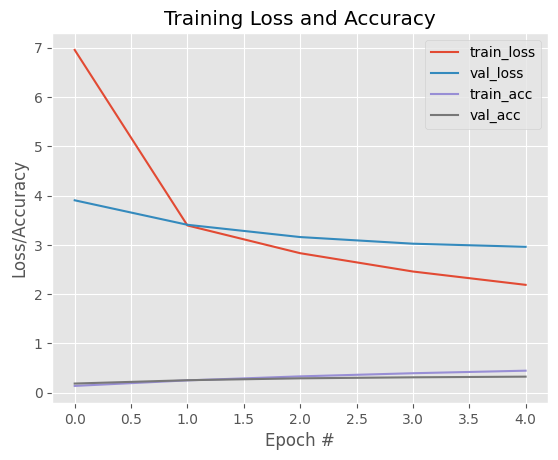

In [56]:
# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.0005),
                          metrics=["accuracy"])

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=5,
                              validation_split=0.2)

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

**Las curvas de train_loss y val_loss** van en direcciones opuestas, mientras que el train_loss parece disminuir con cada época, el val_loss parece disminuir al principio pero posteriormente empieza a subir, lo cual nos indica que tenemos overfitting (los errores mejoran en train pero emperoan en validación)
<br>
**En las curvas de accuracy**, el accuracy en training parece estar subiendo de forma estable, mientras que la curva de accuracy de validación sube al principio y después queda igualada. Esto es otra señal de overfitting (el modelo mejora en training pero en validación no hay mejora)


#### **Fine Tuning**

**Descongelamos partes del base model y aplicamos fine tuning**

Empezamos a descongelar las capas desde atrás, ya que las primeras capas de la red aprenden características más genéricas, mientras que las capas posteriores aprenden características más específicas de la tarea.
Cogemos las últimas cuatro capas por pertenecer al último bloque: block5

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.3760 - loss: 2.4720 - val_accuracy: 0.3777 - val_loss: 2.5194
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.4940 - loss: 1.8769 - val_accuracy: 0.4045 - val_loss: 2.4737
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.6073 - loss: 1.4144 - val_accuracy: 0.4177 - val_loss: 2.5732
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6996 - loss: 1.0590 - val_accuracy: 0.4211 - val_loss: 2.7651
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7576 - loss: 0.8263 - val_accuracy: 0.4213 - val_loss: 3.0317
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8005 - loss: 0.6799 - val_accuracy: 0.4243 - val_loss: 3.1857
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8355 - loss: 0.5449 - val_accuracy: 0.4268 - val_loss: 3.4143
Epoch 8/20
313/313 ━━━━━━━━━━━━━━

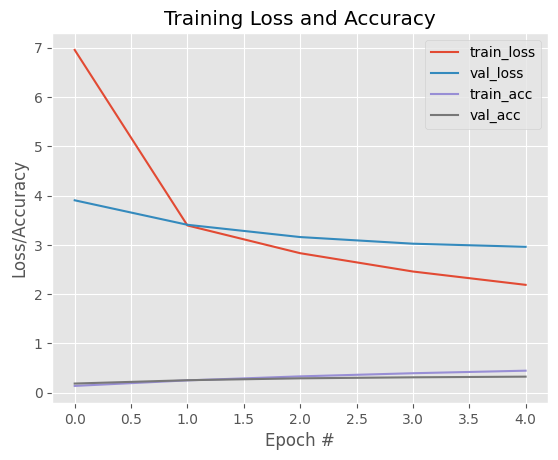

In [57]:
# Descongelamos parte del modelo para aplicar el fine tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompilamos el modelo, pero con un learning rate más bajo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.0001),
                          metrics=["accuracy"])


# Volvemos a entrenar la red
print("[INFO]: Entrenando la red...")
final = pre_trained_model.fit(x_train,
                              y_train,
                              epochs=20,
                              batch_size=128,
                              validation_split=0.2,
                              )
 # Montamos la unidad de Drive
##rive.mount('/content/DL')

# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained_fine_tuned.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Vemos que el resultado ha mejorado (accuracy general 46% vs el 33% inicial). Igualmente, el gráfico es casi idéntico, por lo que los cambios no parecen ser sustanciales. Experimentamos con lo siguiente:
- descongelar más capas
- añadir más capas (flatten, dense, dropout para controlar el overfitting)
- bajar el learning rate aún más
- utilizar EarlyStopping y ReduceLROnPlateau para controlar el overfitting (primero monitorizando el val_loss, pero parece funcionar mejor monitorizando el val_accuracy)
- vemos que el val_accuracy sube y baja a lo largo de las épocas, aunque sea un poco. Por tanto, le damos más épocas al modelo para ver si consigue mejorar un poco más.

ALGUNAS DE LAS PRUEBAS REALIZADAS

Accuracy: 47
- capas descongeladas: -8
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 20

Accuracy: 45

- capas descongeladas: -8
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 40

Accuracy: 48
- capas descongeladas: -12
- dense: 64
- dropout: 0.5
- learning rate: 0.00001
- epocas: 40

Accuracy: 48
- capas descongeladas: -12
- dense: 64
- dropout: 0.1
- learning rate: 0.00001
- epocas: 50

Accuracy: 51
- capas descongeladas: -12
- dense: 64
- dropout: 0.3
- learning rate: 0.00001
- epocas: 40
Parece mejorar con cada época, así que añadimos más épocas, pero hay muy poca mejora.


Accuracy: 52
- capas descongeladas: -12
- dense: 64
- dropout: 0.3
- learning rate: 0.00001
- epocas: 50

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.0144 - loss: 7.0130 - val_accuracy: 0.0271 - val_loss: 4.5485
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.0269 - loss: 4.5342 - val_accuracy: 0.0497 - val_loss: 4.4048
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.0487 - loss: 4.4080 - val_accuracy: 0.0856 - val_loss: 4.2328
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.0694 - loss: 4.2693 - val_accuracy: 0.1318 - val_loss: 4.0424
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.1040 - loss: 4.0954 - val_accuracy: 0.1692 - val_loss: 3.8574
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.1330 - loss: 3.9221 - val_accuracy: 0.2023 - val_loss: 3.6818
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.1671 - loss: 3.7625 - val_accuracy: 0.2408 - val_loss: 3.5282
Epoch 8/50
313/313 ━━━━━━━━━━

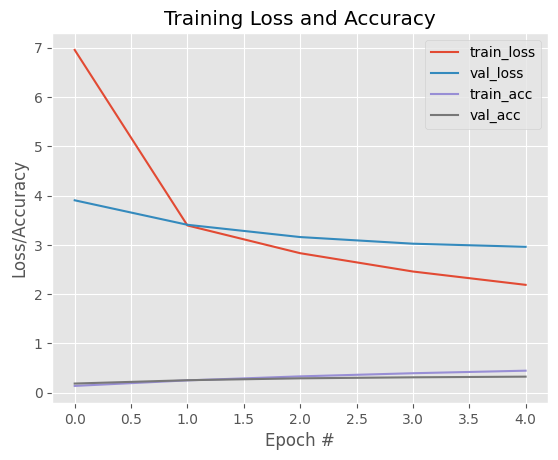

In [38]:
# Descongelamos parte del modelo para aplicar el fine tuning
for layer in base_model.layers[-12:]:
    layer.trainable = True

last = base_model.layers[-1].output
x = Flatten()(last)
x = Dense(64, activation='relu', name='fc1')(x)
x = Dropout(0.3)(x)  # Dropout para controlar overfitting
#x = Dense(64, activation='relu', name='fc2')(x)
x = Dense(100, activation='softmax', name='predictions')(x)



# Creamos el modelo
pre_trained_model = Model(base_model.input, x)

# Recompilamos el modelo, pero con un learning rate más bajo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Volvemos a entrenar la red
print("[INFO]: Entrenando la red...")
final = pre_trained_model.fit(x_train,
                              y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              #callbacks=[early_stopping, lr_scheduler]
                              )
 # Montamos la unidad de Drive
##rive.mount('/content/DL')

# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained_fine_tuned.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

####Conclusiones

Añadir más capas de intensidad no ayuda al modelo, por tanto dejamos una única capa con un valor bajo (se empezó por 524 y se ha ido bajando). Un dropout muy alto o muy bajo no ayuda mucho al overfitting y baja mucho el accuracy, hemos encontrado que el valor óptimo es 0.3.

Hemos visto que durante el fine tuning, el model aprende muy rápido en las primeras épocas, pero a partir de las 30 épocas le cuesta mucho sumar puntos de accuracy.

<p>En conclusión, el modelo parece funcionar mejor sin capas adicionales, simplemente bajando learning rate, añadiendo más épocas y descongelando más capas.

Además, aunque el accuracy parece subir (aunque lentamente), los cambios en el gráfico no son perceptibles.


###**Red 2: MobileNet**


Como segunda red pre-entrenada, elegimos MobileNet por tener una arquitectura muy distinta a la de VGG16, y considerarse un modelo más eficiente (cosa que también comprobamos al mirar sus requerimientos de memoria que en la documentación de Keras son 16MB)

Importamos la arquitectura MobileNet. El preprocesamiento realizado sobre el dataset anteriormente nos sirve también para este modelo (preprocesamiento + OHE), por lo que no hace falta repetirlo.

In [11]:
from tensorflow.keras.applications import MobileNet #DenseNet

In [ ]:
# la sesión se cierra porque se acaba la memoria, bajo de 224 a 128 e igual

from tensorflow.image import resize

# Resize CIFAR-100 images to 224x224
x_train = resize(x_train, (128, 128))
x_test = resize(x_test, (128, 128))

In [ ]:
print(x_train.max())
print(x_train.min())

In [9]:
print("Forma de y_train antes de la conversión:", y_train.shape)
print("Forma de y_test antes de la conversión:", y_test.shape)

Forma de y_train antes de la conversión: (50000, 1)
Forma de y_test antes de la conversión: (10000, 1)


In [10]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [11]:
print("Forma de y_train después de la conversión:", y_train.shape)
print("Forma de y_test después de la conversión:", y_test.shape)

Forma de y_train después de la conversión: (50000, 100)
Forma de y_test después de la conversión: (10000, 100)


In [12]:
from tensorflow.keras.applications import mobilenet

x_train = mobilenet.preprocess_input(x_train)
x_test = mobilenet.preprocess_input(x_test)

In [13]:
print(x_train.max())
print(x_train.min())

1.0
-1.0


**Cargamos el base model**

In [13]:
base_model = MobileNet(weights='imagenet',
                      include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                      input_shape=(128,128,3))
base_model.summary()

<ipython-input-13-6a78936e7ca2>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet',


Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 16, 16, 32)          │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 16, 16, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 16, 16, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 16, 16, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 16, 16, 64)          │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 16, 16, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 8, 8, 64)            │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 8, 8, 64)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 8, 8, 128)           │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 8, 8, 128)           │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 8, 8, 128)           │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 8, 8, 128)           │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 8, 8, 128)           │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

#### **Transfer Learning**

**Congelando el modelo base y creando el top model**

In [17]:
base_model.trainable = False

pre_trained_model = Sequential()

pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(256, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

**Compilando el modelo**

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.0212 - loss: 4.5573 - val_accuracy: 0.0354 - val_loss: 4.4152
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0449 - loss: 4.3972 - val_accuracy: 0.0467 - val_loss: 4.3485
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0521 - loss: 4.3380 - val_accuracy: 0.0504 - val_loss: 4.3171
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0565 - loss: 4.3065 - val_accuracy: 0.0510 - val_loss: 4.3005
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0590 - loss: 4.2869 - val_accuracy: 0.0521 - val_loss: 4.2903
[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

        apple       0.49      0.39      0.44       100
aquarium_fish       0.00      0.00      0.00       100
         baby       0.08      0.05      0.06       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.04      0.01      0.02       100
          bee       0.00      0.00      0.00       100
       beetle       0.10      0.01      0.02       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.07      0.18      0.10       100
         bowl       0.12      0.02      0.03       100
          boy       0.00      0.00      0.00       100
       bridge       0.00      0.00      0.00       100
          bus       0.00      0.00      0.00       100
    butterfly       0.00      0.00      0.00       100
        camel       0.01      0.01      0.01       100
          can       0.10      0.18      0.13       100
       ca

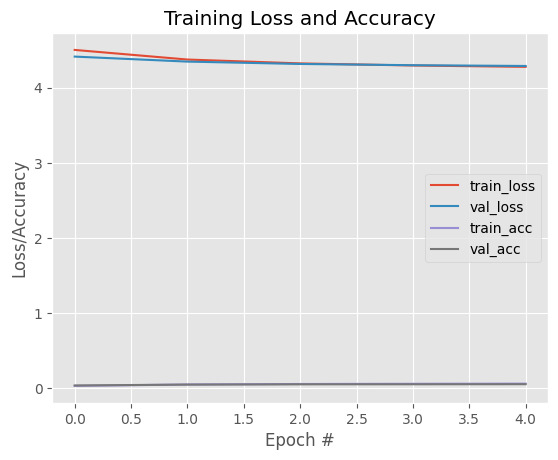

In [18]:
# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.0005),
                          metrics=["accuracy"])

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=5,
                              validation_split=0.2)

# Montamos la unidad de Drive
#drive.mount('/content/DL')
# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.0092 - loss: 6.0057 - val_accuracy: 0.0104 - val_loss: 5.1008
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0111 - loss: 5.7277 - val_accuracy: 0.0122 - val_loss: 5.5457
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0139 - loss: 5.5422 - val_accuracy: 0.0135 - val_loss: 5.4402
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0168 - loss: 5.3992 - val_accuracy: 0.0158 - val_loss: 5.3508
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0208 - loss: 5.2810 - val_accuracy: 0.0195 - val_loss: 5.2622
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0242 - loss: 5.1790 - val_accuracy: 0.0236 - val_loss: 5.1832
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0279 - loss: 5.0887 - val_accuracy: 0.0256 - val_loss: 5.1129
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━

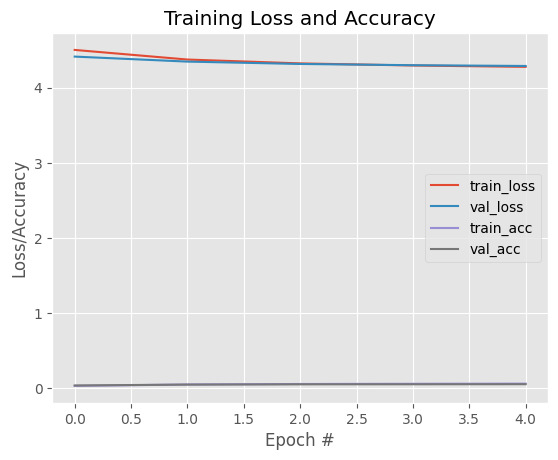

In [19]:
# Descongelamos parte del modelo para aplicar el fine tuning
for layer in base_model.layers[-12:]:
    layer.trainable = True

last = base_model.layers[-1].output
x = Flatten()(last)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dropout(0.5)(x)  # Dropout para controlar overfitting
x = Dense(128, activation='relu', name='fc2')(x)
x = Dense(100, activation='softmax', name='predictions')(x)



# Creamos el modelo
pre_trained_model = Model(base_model.input, x)

# Recompilamos el modelo, pero con un learning rate más bajo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=SGD(learning_rate=0.0001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Volvemos a entrenar la red
print("[INFO]: Entrenando la red...")
final = pre_trained_model.fit(x_train,
                              y_train,
                              epochs=20,
                              batch_size=128,
                              validation_split=0.2,
                              #callbacks=[early_stopping, lr_scheduler]
                              )
 # Montamos la unidad de Drive
##rive.mount('/content/DL')

# Almacenamos el modelo empleando la función mdoel.save de Keras
#pre_trained_model.save(BASE_FOLDER+"deepCNN_CIFAR100_pretrained_fine_tuned.h5")

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

### **Estrategia 2: Entrenar desde cero o from scratch**